# The CLT on a different dataset: Ames sale prices

*Part 1 · Lesson 10 · another dataset  ·  data: Ames housing sale price*

*↩ A companion to [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb).*

**↩ Back:** [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](10-sampling-distributions-clt~the-code.ipynb)

The core lesson watched the **Central Limit Theorem** tame wildly skewed personal incomes. Here we run the
*same* engine on a different lopsided population — the **sale prices of houses in Ames, Iowa** — to drive
home a subtler point: the CLT *always* works, but **how fast** it kicks in depends on the **shape** of the
population. House prices are *more* strongly skewed than most everyday measurements, so their sample
averages need a **bigger sample** before they settle into a clean bell curve. Watching exactly when that
happens is the goal of this lesson.

Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()
rng = np.random.default_rng(7)  # fixed seed -> reproducible; learner can change it

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

# Treat the WHOLE file as the population, so we get to KNOW the true answer.
population = ames['price'].dropna().to_numpy()    # sale price (dollars) of every home
MU    = population.mean()           # the TRUE population mean
SIGMA = population.std(ddof=0)      # the TRUE population standard deviation
N_POP = len(population)
print(f'Population: {N_POP:,} Ames home sales')
print(f'TRUE mean    MU     = ${MU:,.0f}')
print(f'TRUE median         = ${np.median(population):,.0f}')
print(f'TRUE stdev   SIGMA  = ${SIGMA:,.0f}')
print(f'Skewness            = {stats.skew(population):.2f}   (0 = symmetric; this is strongly right-skewed)')

Population: 2,930 Ames home sales
TRUE mean    MU     = $180,796
TRUE median         = $160,000
TRUE stdev   SIGMA  = $79,873
Skewness            = 1.74   (0 = symmetric; this is strongly right-skewed)


## 1) The population — a shape that is *not* a bell curve

Before we average anything, look at the raw data. These are sale prices for every home in the file, and
like most price data they are strongly **right-skewed**: a big crowd of modest and mid-range homes, then a
long thin tail of a few expensive houses stretching far to the right.

- **The math:** the *skewness* statistic measures lopsidedness. A symmetric bell curve has skewness $0$.
  This population's skewness is about $+1.74$ — clearly lopsided to the right.
- **What the number means:** the average price (about 180,800 dollars) sits well **above** the typical
  (median) home (about 160,000 dollars). The handful of expensive houses in the tail drag the average up,
  so half the homes sell for less than the median while the mean is pulled higher.
- **What it says about the world:** this is exactly the kind of messy, real-world distribution where you
  might *expect* tidy statistics to break down. And it is **more skewed** than the living-*area* data the
  flagship confidence-interval lesson uses (skew about $+1.27$). Hold that contrast in mind — it is the
  whole point of this lesson.

*(A reminder on notation: in plain text we write prices as "180,800 dollars" rather than with a currency
symbol, because the dollar sign has a special math meaning in these notebooks.)*

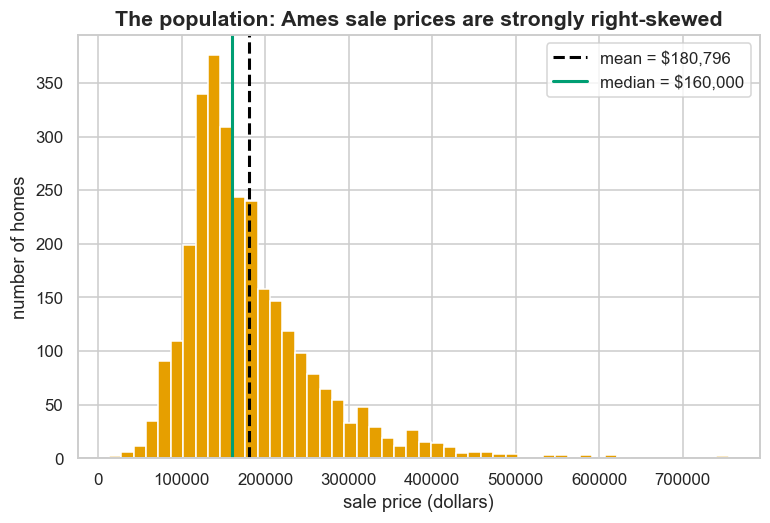

Notice: the mean sits to the RIGHT of the median - the long tail of pricey homes pulls it up.
Population skewness = 1.74  (compare living area, skew ~1.27 - prices are worse)


In [2]:
fig, ax = plt.subplots()
ax.hist(population, bins=50, color='#E69F00', edgecolor='white')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'mean = ${MU:,.0f}')
ax.axvline(np.median(population), color='#009E73', lw=2,
           label=f'median = ${np.median(population):,.0f}')
ax.set_xlabel('sale price (dollars)')
ax.set_ylabel('number of homes')
ax.set_title('The population: Ames sale prices are strongly right-skewed')
ax.legend(); plt.show()
print('Notice: the mean sits to the RIGHT of the median - the long tail of pricey homes pulls it up.')
print(f'Population skewness = {stats.skew(population):.2f}  (compare living area, skew ~1.27 - prices are worse)')

## 2) One sample — the sample mean is itself just *one* random number

In real life you can't appraise every house. You take a **sample**. Here we draw $n = 30$ homes at random
and compute their average price, $\bar{x}$ ("x-bar").

- **The math:** $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — add up the 30 prices, divide by 30.
- **What the number means:** $\bar{x}$ is our *estimate* of the unknown population mean $\mu$.
- **What it says about the world:** this single number is a **roll of the dice**. Draw a different 30 homes
  and you'd get a different $\bar{x}$. So $\bar{x}$ is not a fixed fact — it is a **random variable** with a
  distribution of its own. Mapping that distribution is the whole point of the lesson.

> **An honest note on how we sample.** We draw with `replace=True`, meaning a home could in principle be
> picked twice. This models drawing from an effectively *infinite* population of similar i.i.d. homes (not
> a finite once-each survey), which is what makes $\sigma/\sqrt{n}$ the **exact** target for the spread we
> measure later.

**Try it:** the next cell draws *two* different samples so you can see two different averages — and if you
press **Shift + Enter** on it a few times, the number keeps landing somewhere new. That jiggle is exactly
what we're about to map.

In [3]:
n = 30
one_sample = rng.choice(population, size=n, replace=True)
xbar = one_sample.mean()
print(f'This sample of {n} homes had mean price   xbar = ${xbar:,.0f}')
print(f'The true population mean is                MU   = ${MU:,.0f}')
print()
xbar2 = rng.choice(population, size=n, replace=True).mean()
print(f'A second random sample of {n} gave         xbar = ${xbar2:,.0f}')
print('Different sample -> different mean. xbar wobbles. That wobble has a shape.')

This sample of 30 homes had mean price   xbar = $223,770
The true population mean is                MU   = $180,796

A second random sample of 30 gave         xbar = $162,942
Different sample -> different mean. xbar wobbles. That wobble has a shape.


## 3) Many samples — the *sampling distribution* of the mean

So let's stop looking at one $\bar{x}$ and look at *thousands* of them. We'll repeat "draw 30 homes, record
their average price" **5,000 times** and histogram the 5,000 averages. That histogram is the **sampling
distribution of the mean**. *(It's drawn on a **density** scale — area sums to 1 — so we can lay the
predicted bell curve right on top; don't worry about the exact y-axis numbers, only the shape.)*

Watch what happens to the shape — and watch for a little skew that *lingers*, because this population is so
lopsided.

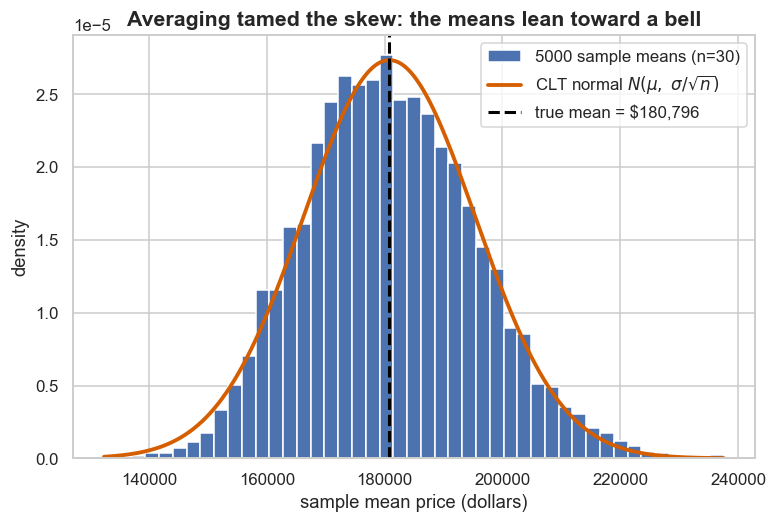

Skew of the raw population:   1.74   (strongly right-skewed)
Skew of the 5,000 means:      0.25   (down a lot, but some right-skew still lingers at n=30)
Center of the means:        $181,063   (vs true MU = $180,796)


In [4]:
n = 30
n_reps = 5000
sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                         for _ in range(n_reps)])

fig, ax = plt.subplots()
ax.hist(sample_means, bins=45, density=True, color='#4c72b0', edgecolor='white',
        label=f'{n_reps} sample means (n={n})')
# Overlay the Central Limit Theorem's prediction: a normal bell curve.
xs = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA / np.sqrt(n)),
        color='#D55E00', lw=2.5, label=r'CLT normal $N(\mu,\ \sigma/\sqrt{n})$')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'true mean = ${MU:,.0f}')
ax.set_xlabel('sample mean price (dollars)'); ax.set_ylabel('density')
ax.set_title('Averaging tamed the skew: the means lean toward a bell')
ax.legend(); plt.show()

print(f'Skew of the raw population:   {stats.skew(population):.2f}   (strongly right-skewed)')
print(f'Skew of the 5,000 means:      {stats.skew(sample_means):.2f}   (down a lot, but some right-skew still lingers at n=30)')
print(f'Center of the means:        ${sample_means.mean():,.0f}   (vs true MU = ${MU:,.0f})')

**What just happened?** The raw prices were strongly skewed (skewness about $+1.74$), yet their **averages**
are far more symmetric — a rough bell **centered right on the true mean** $\mu$ that already hugs the red
curve. (A noticeable right-skew still lingers, more than the income example in the core lesson showed at the
same $n=30$, precisely *because* prices start out more lopsided. Section 4 shows it keeps improving as $n$
grows.) That red curve is the **Central Limit Theorem (CLT)** at work:

$$\bar{x} \;\approx\; N\!\left(\mu,\ \frac{\sigma}{\sqrt{n}}\right)$$

- **The math:** for large enough $n$, the sampling distribution of $\bar{x}$ is approximately **normal**,
  with mean $\mu$ and standard deviation $\sigma/\sqrt{n}$ — *no matter what shape the population has*.
- **What it means:** averaging is a **smoothing machine**. One expensive mansion can blow up a single
  price, but it gets diluted by 29 ordinary homes, so extreme averages are rare.
- **What it says about the world:** even from messy real prices, we can describe how $\bar{x}$ behaves with
  a clean, predictable curve. *That* is what lets us put honest error bars on estimates.

## 4) The effect of $n$ — and how skew sets the speed

The CLT is a story about growing $n$. Let's draw the sampling distribution for four sample sizes side by
side: $n = 5, 10, 30, 50$. With a population this lopsided, the small samples are the interesting part.

- $n = 5$ and $n = 10$ are still **visibly right-skewed** — a tell-tale lean and a longer right tail. The
  CLT has **not fully kicked in** yet, because the population is so skewed to begin with.
- By $n \approx 30$ to $50$ the histogram looks **bell-shaped and symmetric** — the CLT has won.

This is the contrast to remember: a milder population would look bell-shaped by $n = 10$ or so, but these
strongly-skewed prices need a bigger sample to get there. **The more skewed the population, the larger the
$n$ the CLT needs.**

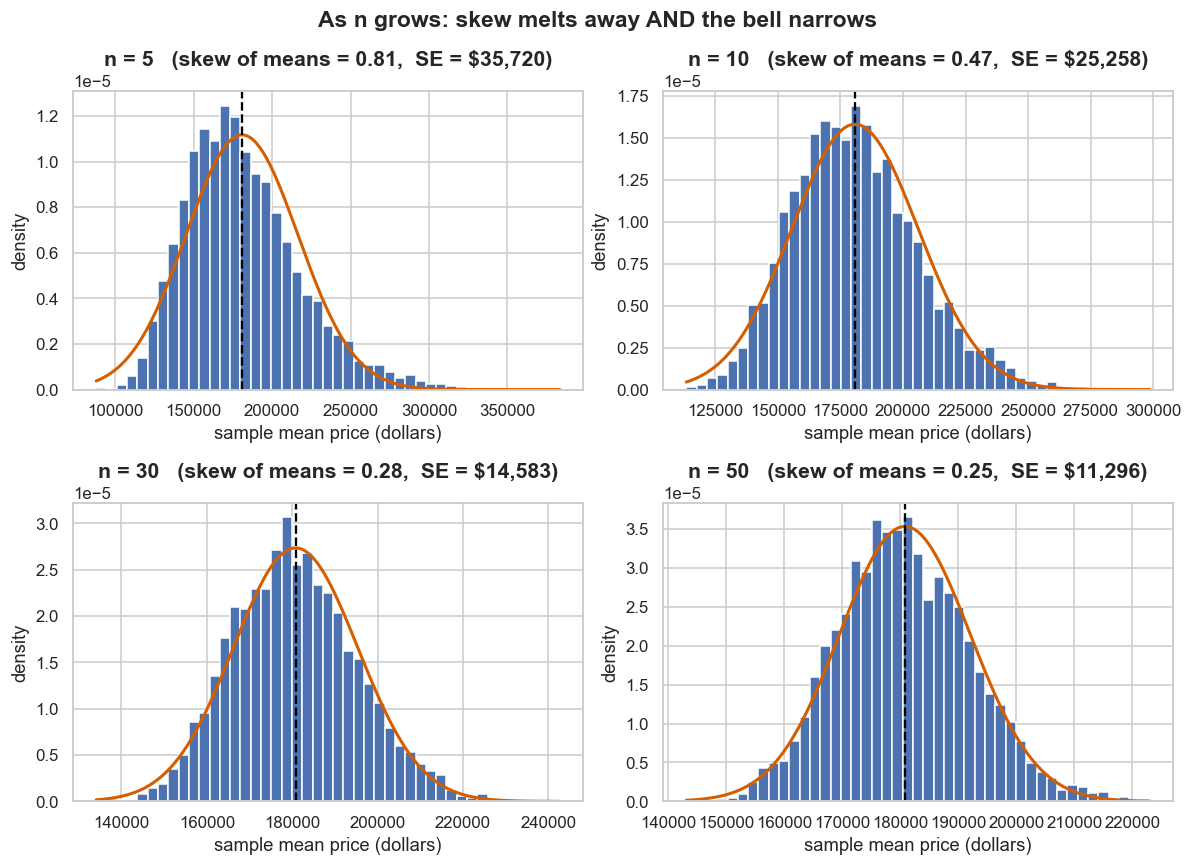

n=5 and n=10 still lean right (skew well above 0). By n=30-50 the bell is symmetric.
A LESS-skewed population would get there sooner; these prices need a bigger n.


In [5]:
sizes = [5, 10, 30, 50]
n_reps = 5000

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, n in zip(axes.ravel(), sizes):
    means = np.array([rng.choice(population, size=n, replace=True).mean()
                      for _ in range(n_reps)])
    ax.hist(means, bins=45, density=True, color='#4c72b0', edgecolor='white')
    xs = np.linspace(means.min(), means.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA / np.sqrt(n)), color='#D55E00', lw=2)
    ax.axvline(MU, color='black', lw=1.5, ls='--')
    ax.set_title(f'n = {n}   (skew of means = {stats.skew(means):.2f},  SE = ${SIGMA/np.sqrt(n):,.0f})')
    ax.set_xlabel('sample mean price (dollars)'); ax.set_ylabel('density')
fig.suptitle('As n grows: skew melts away AND the bell narrows', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print('n=5 and n=10 still lean right (skew well above 0). By n=30-50 the bell is symmetric.')
print('A LESS-skewed population would get there sooner; these prices need a bigger n.')

Two things happen at once as $n$ climbs: the shape becomes **more bell-like** (the leftover skew melts
away), and the spread gets **narrower** (the averages cluster tighter around $\mu$). The skew-of-means
number printed in each title is the scoreboard: it starts clearly positive at $n = 5$ and slides toward
$0$ by $n = 50$.

## 5) The standard error and the $\sqrt{n}$ law

How wide is that bell? Its standard deviation has a special name — the **standard error (SE)** — and a
beautifully simple formula:

$$\text{SE} \;=\; \frac{\sigma}{\sqrt{n}}$$

- **The math:** divide the population's standard deviation $\sigma$ by the square root of the sample size.
- **What it means:** the SE is the typical "give or take" of a single sample mean — how far $\bar{x}$
  usually lands from the true $\mu$.
- **What it says about the world:** precision improves only with the **square root** of $n$. Because of
  that $\sqrt{n}$, to **halve** your error you must **quadruple** your sample. Effort buys precision, but at
  a diminishing rate.

First, let's confirm the formula against our simulation — note that even though the bell at $n = 30$ still
carries a little skew, the **spread** formula is already dead-on. (Skew fades with $n$; the SE formula is
exact at *every* $n$.)

In [6]:
n = 30
sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                         for _ in range(5000)])
empirical_se = sample_means.std()
theory_se    = SIGMA / np.sqrt(n)
print(f'Std of the 5,000 sample means (measured) = ${empirical_se:,.0f}')
print(f'CLT prediction  sigma/sqrt(n)            = ${theory_se:,.0f}')
print(f'They match to within ${abs(empirical_se - theory_se):,.0f} -> the SE formula really describes the wobble of xbar.')

Std of the 5,000 sample means (measured) = $14,473
CLT prediction  sigma/sqrt(n)            = $14,583
They match to within $110 -> the SE formula really describes the wobble of xbar.


In [7]:
# Check the formula across a range of n: empirical spread vs sigma/sqrt(n).
sizes = [5, 10, 30, 50, 100, 200]
rows = []
for nn in sizes:
    means = np.array([rng.choice(population, size=nn, replace=True).mean() for _ in range(4000)])
    rows.append({'n': nn,
                 'empirical_SE': means.std(ddof=0),
                 'formula_SE': SIGMA / np.sqrt(nn)})
se_table = pd.DataFrame(rows)
print(se_table.to_string(index=False, float_format=lambda v: f'{v:,.0f}'))
print()
print('Quadruple n (e.g. 50 -> 200) and the SE roughly HALVES. That is the sqrt(n) law.')
se50  = se_table.loc[se_table['n'] == 50,  'formula_SE'].iloc[0]
se200 = se_table.loc[se_table['n'] == 200, 'formula_SE'].iloc[0]
print(f'  SE at n=50  = ${se50:,.0f}')
print(f'  SE at n=200 = ${se200:,.0f}   (about half - 4x the data halved the error)')

  n  empirical_SE  formula_SE
  5        36,239      35,720
 10        24,732      25,258
 30        14,313      14,583
 50        11,267      11,296
100         7,811       7,987
200         5,649       5,648

Quadruple n (e.g. 50 -> 200) and the SE roughly HALVES. That is the sqrt(n) law.
  SE at n=50  = $11,296
  SE at n=200 = $5,648   (about half - 4x the data halved the error)


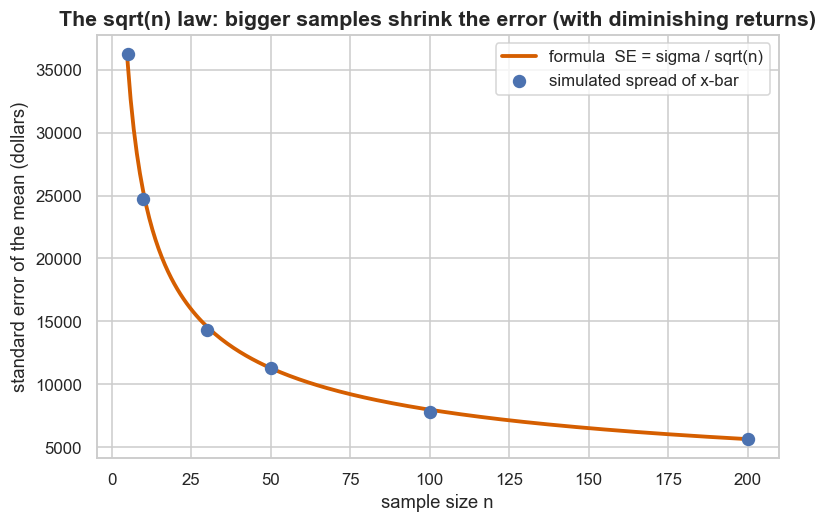

The simulated dots land right on the formula curve, and the curve flattens: each
extra home helps less than the one before. That flattening is the sqrt(n) law.


In [8]:
# Picture the sqrt(n) law: dots = simulation, smooth curve = sigma/sqrt(n).
nn_grid = np.linspace(5, 200, 200)
fig, ax = plt.subplots()
ax.plot(nn_grid, SIGMA / np.sqrt(nn_grid), color='#D55E00', lw=2.5,
        label=r'formula  SE = sigma / sqrt(n)')
ax.scatter(se_table['n'], se_table['empirical_SE'], s=60, color='#4c72b0', zorder=5,
           label='simulated spread of x-bar')
ax.set_xlabel('sample size n'); ax.set_ylabel('standard error of the mean (dollars)')
ax.set_title('The sqrt(n) law: bigger samples shrink the error (with diminishing returns)')
ax.legend(); plt.show()
print('The simulated dots land right on the formula curve, and the curve flattens: each')
print('extra home helps less than the one before. That flattening is the sqrt(n) law.')

## 6) The bridge — why this powers confidence intervals

Here is the payoff that the rest of the course rests on. We now know that a sample mean behaves like:

$$\bar{x} \;\approx\; N\!\left(\mu,\ \frac{\sigma}{\sqrt{n}}\right)$$

Because that distribution is **normal**, we can borrow the bell curve's famous **68–95–99.7 rule**: about
**95%** of sample means land within roughly **2 standard errors** of the true mean $\mu$. Turn that around —
for about 95% of samples, the true $\mu$ lies within $\pm 2\,\text{SE}$ of the $\bar{x}$ you observed. That
window,

$$\bar{x} \;\pm\; (\text{about } 2)\cdot \frac{\sigma}{\sqrt{n}},$$

is a **95% confidence interval**.

This is the exact engine behind the **flagship confidence-interval lesson**, which samples Ames living
*area* and watches about 95 of 100 intervals capture the true mean. Now you can see *why* that coverage
holds even though the area data is skewed: the CLT makes the sample mean approximately normal, and at the
sample sizes used the leftover skew is small. Prices are *more* skewed than area, so they'd need a slightly
bigger $n$ for the same quality of bell — same idea, just a touch slower.

Let's see the "about 95% land within 2 SE" promise directly in our price simulation. We use $n = 50$, where
the bell is already nicely symmetric.

In [9]:
n = 50
sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                         for _ in range(8000)])
SE = SIGMA / np.sqrt(n)
within2 = np.mean(np.abs(sample_means - MU) <= 2 * SE) * 100
print(f'At n = {n}: sample means landing within 2 SE of the true mean: {within2:.1f}%')
print(f'The 68-95-99.7 rule predicts about 95%.')
print()
print('That 95% is the seed of the confidence interval - the flagship demo grows it')
print('into 100 real intervals (on Ames living area) and counts how many catch the true mean.')

At n = 50: sample means landing within 2 SE of the true mean: 95.8%
The 68-95-99.7 rule predicts about 95%.

That 95% is the seed of the confidence interval - the flagship demo grows it
into 100 real intervals (on Ames living area) and counts how many catch the true mean.


## Now you try

Predict what will happen, then change one thing and re-run:

1. **Shrink the sample.** Scroll up to the first code cell under heading **3**, find the line that reads
   `n = 30`, change the `30` to `5`, and press **Shift + Enter** on that cell. Does the bell get *fatter*?
   Does a clear right-skew come back? (It should — at $n = 5$ this very skewed population hasn't been tamed
   yet.)

2. **Try a milder variable for contrast.** Living *area* is less skewed than price. In the setup cell, set
   `population = ames['area'].dropna().to_numpy()`, re-run setup and section 4. At $n = 10$, does area look
   *more* bell-shaped than price did? (It should — milder skew, faster CLT.)

3. **Test the $\sqrt{n}$ law yourself.** In the section-5 table, the SE at `n = 50` is printed. Predict the
   SE at `n = 200` *before looking* — divide the `n = 50` value by $\sqrt{200/50} = \sqrt{4} = 2$. Then
   check it against the table.

4. **Change the seed.** Swap `np.random.default_rng(7)` in the setup cell for any other number and re-run.
   Your individual sample means move, but does the overall *shape* and *spread* of the sampling
   distribution change much? Why or why not?

## What you learned

- A statistic like the sample mean $\bar{x}$ is itself **random**; the distribution of its possible values
  is the **sampling distribution**.
- The **Central Limit Theorem**: for large enough $n$, $\bar{x} \approx N(\mu,\ \sigma/\sqrt{n})$ — a
  **bell curve centered on the true mean** — *even when the population is strongly skewed*, as Ames prices
  are (skew about $+1.74$).
- **How fast** the bell appears depends on the population's **shape**: the more skewed the data, the larger
  the $n$ needed. Prices still leaned right at $n = 5$ and $n = 10$, and only looked symmetric by
  $n \approx 30$ to $50$ — slower than a milder distribution would.
- The **standard error** $\text{SE} = \sigma/\sqrt{n}$ is the spread of that bell, and the simulation
  matched it at every $n$. The $\sqrt{n}$ law means **quadrupling $n$ only halves the error**.
- Because $\bar{x}$ is approximately normal, about **95% of sample means fall within ~2 SE of $\mu$** — the
  foundation of the **confidence interval**, which the flagship lesson builds on Ames living area for
  exactly this reason.

---

**↩ Back to the lesson:** [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](10-sampling-distributions-clt~the-code.ipynb)